# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?  

Adding a penalty that grows with the size of the coefficients makes the model to pay a cost for trying to fit a feature hard.  The penalty pushes coefficients toward zero unless the data really justify them.


2. How does regularization provide a way of exploring the bias-variance trade-off?  

As you increase regularization you introduce more bias, so the model can't fit the data as closely.  But it reduces variance because the coefficients are smaller, so they vary the output less across different samples.


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?  

Ridge uses an L2 penalty and LASSO uses an L1 penalty. Ridge shrinks all coefficients toward zero but keeps them all nonzero. LASSO can push coefficients exactly to zero, so it can also mute variables. LASSO gives you a sparse model and ridge gives you a denser one with smaller coefficients.


4. How do we typically scale variables for use in regularized regression? Why?

 We z-score standardize which is subtract mean and divide by standard deviation. Without scaling, the penalty treats a coefficient on a variable measured in thousands the same as one on a variable measured in fractions, which distorts the features and how the model sees them.


5. How is the penalty $\alpha$ typically selected?  

Cross validation. You fit the model across a grid of alpha values and pick the one that minimizes the average test error.


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?  

No. The penalty is for regularization, not part of the loss. You're using Cross val to estimate how well the model predicts new data, and that doesn't involve the penalty.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.metrics import mean_squared_error

In [6]:
cars = pd.read_csv("../data/cars_hw.csv", index_col=0)
cars['Age'] = cars['Make_Year'].max() - cars['Make_Year'] + 1

poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()

X_raw = cars[['Mileage_Run', 'Age']].values
X_poly = poly.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_poly)
feat_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
y_cars = cars['Price'].values

print("Feature names:", feat_names)
print("Shape:", X_scaled.shape)

Feature names: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
Shape: (976, 9)


In [7]:
lr_cars = LinearRegression().fit(X_scaled, y_cars)
coef_df = pd.DataFrame({'feature': feat_names, 'coef': lr_cars.coef_})
print(coef_df)

             feature          coef
0        Mileage_Run  5.592672e+05
1                Age -1.583859e+05
2      Mileage_Run^2 -1.205555e+05
3    Mileage_Run Age -1.066665e+06
4              Age^2  1.605177e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  2.559884e+05
7  Mileage_Run Age^2  4.448972e+05
8              Age^3 -1.094785e+05


The coefficient on Mileage_Run Age is negative — about -1,066,665. So a car that is old and high-mileage gets penalized more than you'd expect from age and mileage separately. That makes sense because an old car that's also been driven a lot is a double signal of wear so really not attractive.

In [8]:
alphas = np.logspace(1, 3, 20)
lasso_cars = LassoCV(alphas=alphas, cv=20, max_iter=10000).fit(X_scaled, y_cars)
print(f"Best alpha: {lasso_cars.alpha_:.2f}")

Best alpha: 615.85


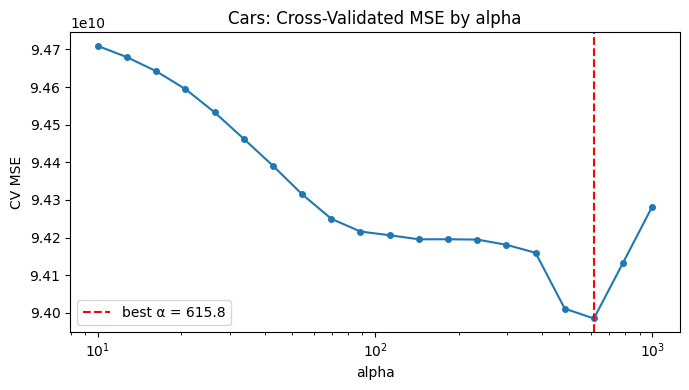

In [9]:
# CV MSE by alpha
mean_mse = lasso_cars.mse_path_.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lasso_cars.alphas_, mean_mse, marker='o', ms=4)
ax.axvline(lasso_cars.alpha_, color='red', linestyle='--', label=f'best α = {lasso_cars.alpha_:.1f}')
ax.set_xlabel('alpha')
ax.set_ylabel('CV MSE')
ax.set_title('Cars: Cross-Validated MSE by alpha')
ax.legend()
plt.tight_layout()
plt.show()

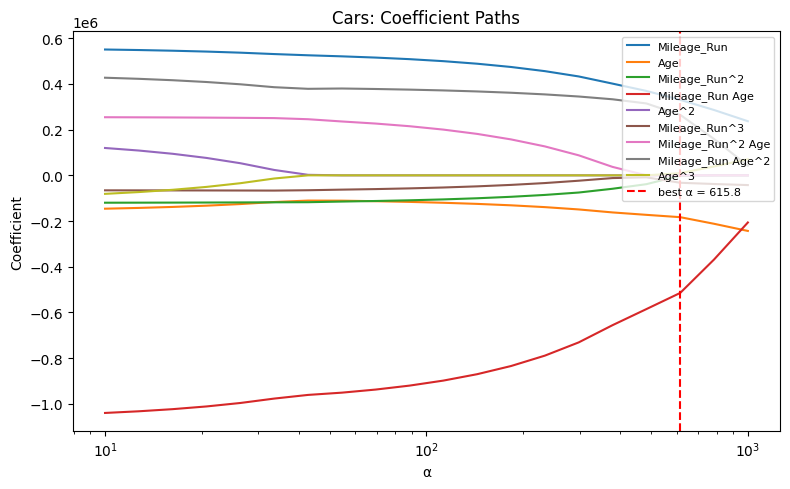

In [10]:
# Coefficient paths
alphas_path, coefs_path, _ = lasso_path(X_scaled, y_cars, alphas=alphas, max_iter=10000)

fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(feat_names):
    ax.semilogx(alphas_path, coefs_path[i], label=name)
ax.axvline(lasso_cars.alpha_, color='red', linestyle='--', label=f'best α = {lasso_cars.alpha_:.1f}')
ax.set_xlabel('α')
ax.set_ylabel('Coefficient')
ax.set_title('Cars: Coefficient Paths')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
lasso_coef_df = pd.DataFrame({
    'feature': feat_names,
    'lr_coef': lr_cars.coef_,
    'lasso_coef': lasso_cars.coef_
})
print(lasso_coef_df.to_string(index=False))
nonzero = np.sum(lasso_cars.coef_ != 0)
total = len(lasso_cars.coef_)
print(f"\nSelected: {nonzero}/{total}, zero proportion: {(total - nonzero)/total:.2f}")

          feature       lr_coef     lasso_coef
      Mileage_Run  5.592672e+05  330751.620711
              Age -1.583859e+05 -182402.178991
    Mileage_Run^2 -1.205555e+05      -0.000000
  Mileage_Run Age -1.066665e+06 -517427.140509
            Age^2  1.605177e+05      -0.000000
    Mileage_Run^3 -6.514490e+04  -33288.436666
Mileage_Run^2 Age  2.559884e+05       0.000000
Mileage_Run Age^2  4.448972e+05  266929.590696
            Age^3 -1.094785e+05    8967.626813

Selected: 6/9, zero proportion: 0.33


6 of 9 features are selected, so about 33% are zeroed out. The three terms set to zero are `Mileage_Run^2`, `Age^2`, and `Mileage_Run^2 Age` they're basically quadratic mileage terms and their interaction.

7. A few things stand out. No coefficient flips sign and the directions stay consistent between OLS and LASSO. The big OLS coefficients (`Mileage_Run Age` at -1.07M, `Mileage_Run Age^2` at +445K) get shrunk but keep their signs. Nothing increases in magnitude going from OLS to LASSO, which is expected because regularization is supposed to shrink. The coefficient paths show `Mileage_Run` and `Mileage_Run Age` are the last to survive as as alpha grows, so they have the most signal.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
heart = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")
print(heart.shape)
heart.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/heart_failure_clinical_records_dataset.csv'

In [ ]:
# Continuous features: third-degree polynomial, then scale
poly3 = PolynomialFeatures(degree=3, include_bias=False)
scaler3 = StandardScaler()

X_cont = poly3.fit_transform(heart[['age', 'ejection_fraction', 'serum_creatinine']].values)
X_cont_scaled = scaler3.fit_transform(X_cont)
cont_names = poly3.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

# Categorical features: pairwise interactions only
poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_int.fit_transform(heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']].values)
cat_names = poly_int.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

X_all = np.hstack([X_cont_scaled, X_cat])
all_names = list(cont_names) + list(cat_names)
y_heart = heart['DEATH_EVENT'].values

print(f"Total features: {X_all.shape[1]}")
print("Features:", all_names)

Total features: 29
Features: ['age', 'ejection_fraction', 'serum_creatinine', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^3', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction serum_creatinine^2', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']


In [ ]:
lr_heart = LinearRegression().fit(X_all, y_heart)
coef_heart = pd.DataFrame({'feature': all_names, 'coef': lr_heart.coef_})
print(coef_heart)

                                   feature      coef
0                                      age  1.539156
1                        ejection_fraction -2.192494
2                         serum_creatinine -0.853588
3                                    age^2 -3.678654
4                    age ejection_fraction -0.600918
5                     age serum_creatinine  1.841563
6                      ejection_fraction^2  3.430976
7       ejection_fraction serum_creatinine  2.673394
8                       serum_creatinine^2 -2.647041
9                                    age^3  1.993135
10                 age^2 ejection_fraction  0.908026
11                  age^2 serum_creatinine -0.697522
12                 age ejection_fraction^2 -0.081206
13  age ejection_fraction serum_creatinine -1.577665
14                  age serum_creatinine^2  1.284099
15                     ejection_fraction^3 -1.250341
16    ejection_fraction^2 serum_creatinine -1.270043
17    ejection_fraction serum_creatinine^2  1.

A few counterintuitive signs are that ejection_fraction is how well the heart pumps and is negative at the linear level, which seems right.higher ejection fraction should mean better survival, so negative = less death. But serum_creatinine (high values = kidney stress) is also negative at the linear term, which isn't what i would have though. I'd expect higher creatinine to mean more death. What's happening is that the polynomial terms are absorbing the actual nonlinear relationship, so the linear term alone doesn't show the actual effect. The higher-order terms can flip the linear slope to produce the overall right shape.

In [ ]:
alphas_h = np.logspace(-5, 5, 30)
lasso_heart = LassoCV(alphas=alphas_h, cv=20, max_iter=100000).fit(X_all, y_heart)
print(f"Best alpha: {lasso_heart.alpha_:.6f}")

Best alpha: 0.005736


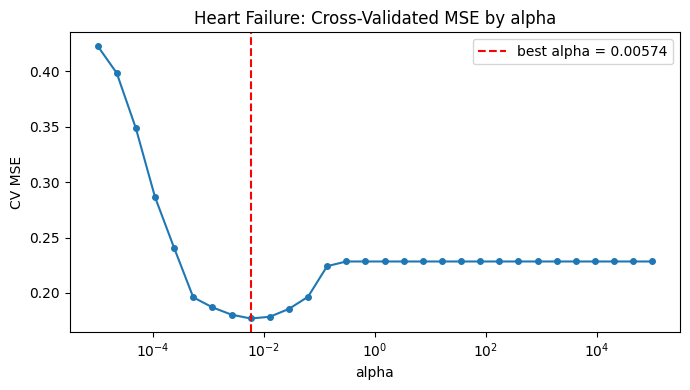

In [ ]:
mean_mse_h = lasso_heart.mse_path_.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lasso_heart.alphas_, mean_mse_h, marker='o', ms=4)
ax.axvline(lasso_heart.alpha_, color='red', linestyle='--', label=f'best alpha = {lasso_heart.alpha_:.5f}')
ax.set_xlabel('alpha')
ax.set_ylabel('CV MSE')
ax.set_title('Heart Failure: Cross-Validated MSE by alpha')
ax.legend()
plt.tight_layout()
plt.show()

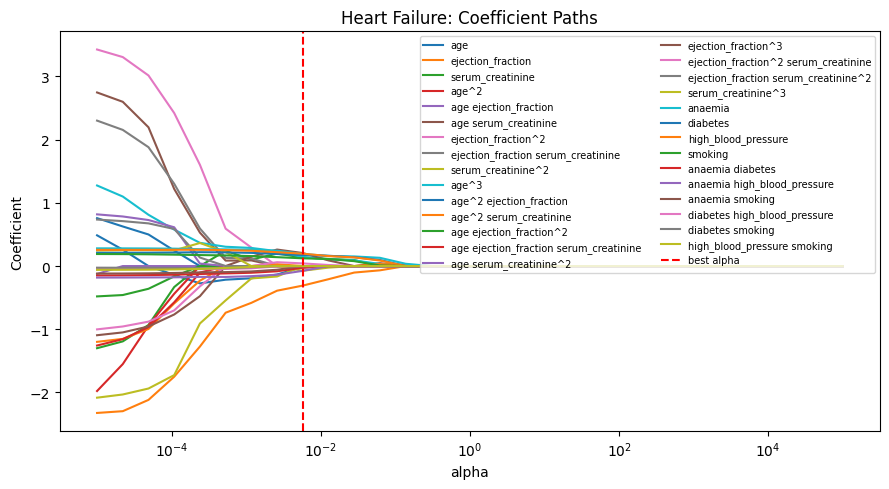

In [ ]:
alphas_path_h, coefs_path_h, _ = lasso_path(X_all, y_heart, alphas=alphas_h, max_iter=100000)

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(all_names):
    ax.semilogx(alphas_path_h, coefs_path_h[i], label=name)
ax.axvline(lasso_heart.alpha_, color='red', linestyle='--', label=f'best alpha')
ax.set_xlabel('alpha')
ax.set_ylabel('Coefficient')
ax.set_title('Heart Failure: Coefficient Paths')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
coef_compare = pd.DataFrame({
    'feature': all_names,
    'lr_coef': lr_heart.coef_,
    'lasso_coef': lasso_heart.coef_
})
print(coef_compare.to_string(index=False))

nonzero_h = np.sum(lasso_heart.coef_ != 0)
total_h = len(lasso_heart.coef_)
print(f"\nSelected: {nonzero_h}/{total_h}, zero proportion: {(total_h - nonzero_h)/total_h:.2f}")

                               feature   lr_coef  lasso_coef
                                   age  1.539156   -0.000000
                     ejection_fraction -2.192494   -0.329656
                      serum_creatinine -0.853588    0.116875
                                 age^2 -3.678654    0.000000
                 age ejection_fraction -0.600918   -0.000000
                  age serum_creatinine  1.841563    0.000000
                   ejection_fraction^2  3.430976    0.000000
    ejection_fraction serum_creatinine  2.673394    0.000000
                    serum_creatinine^2 -2.647041   -0.000000
                                 age^3  1.993135    0.117992
               age^2 ejection_fraction  0.908026    0.000000
                age^2 serum_creatinine -0.697522    0.000000
               age ejection_fraction^2 -0.081206    0.000000
age ejection_fraction serum_creatinine -1.577665    0.000000
                age serum_creatinine^2  1.284099   -0.000000
                   eject

12 of 29 features are selected, so about 59% are zeroed out. The surviving features are `ejection_fraction`, `serum_creatinine`, `age^3`, `ejection_fraction^3`, `ejection_fraction^2 serum_creatinine`, `serum_creatinine^3`, `anaemia`, `diabetes`, `high_blood_pressure`, `diabetes high_blood_pressure`, `diabetes smoking`, and `high_blood_pressure smoking`.

On the sign/magnitude comparisons: several OLS coefficients are huge and opposite in sign to what I'd expect.  The polynomial terms especially. The LASSO versions are much smaller and make more sense. `ejection_fraction` goes from -2.19 (OLS) to -0.33 (LASSO), same direction but way more stable. `serum_creatinine` flips from -0.85 (OLS) to +0.12 (LASSO).  The LASSO sign is actually the right one: higher creatinine = worse kidney function = more death. 

This is the bias-variance tradeoff. OLS with 29 features on 299 observations has so much variance that the coefficients become unreliable and they're fitting noise. LASSO forces most coefficients to zero and shrinks the rest, introducing some bias but hugely reducing variance. The result is coefficient estimates that are smaller, make more sense, and are more consistent with what we intuitively think.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. You just take the regular MSE and tack the penalty on at the end. The model still wants to minimize prediction error, but now it also has to pay a cost for making $b_1$ large:

$$
L(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

the penalty is only on b1 because b0 is just a shift so its not really adding complexity.

Take derivatives and set to zero:

$$
\frac{\partial L}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0
$$

Since $\sum \tilde{y}_i = 0$ and $\sum \tilde{x}_i = 0$, this gives $b_0 = 0$.

$$
\frac{\partial L}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_1 = 0
$$

Rearrange

$$
\frac{1}{n}\sum_i \tilde{x}_i \tilde{y}_i - b_1 \frac{1}{n}\sum_i \tilde{x}_i^2 + \alpha b_1 = 0
$$

$$
b_1 = \frac{\frac{1}{n}\sum_i \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum_i \tilde{x}_i^2 + \alpha}
$$

As $\alpha$ increases, the denominator $\frac{1}{n}\sum \tilde{x}_i^2 + \alpha$ gets larger while the numerator stays fixed. So $b_1$ shrinks toward zero. The bigger $\alpha$, the harder it penalizes large slopes, and the closer to zero the output gets. It doesn't hit zero though, it just is an asymptote.

The problem with L1 is that $|b_1|$ is not differentiable at $b_1 = 0$ because theres a vertex in the graph. So you can't just take a derivative and set it to zero.

The right way to think about it is to compare the pull from the squared-error part to the size of the penalty. If $b_1=0$, the derivative of the squared-error term is
$$
-\frac{2}{n}\sum_i \tilde{x}_i \tilde{y}_i.
$$
For $b_1=0$ to be optimal, this has to be small enough that the L1 penalty can balance it. That happens when
$$
\left| \frac{2}{n}\sum_i \tilde{x}_i \tilde{y}_i \right| \le \alpha,
$$

So LASSO sets $b_1=0$ when the correlation between $\tilde{x}$ and $\tilde{y}$ is not strong enough to overcome the penalty. If that correlation is larger than this threshold,
then the optimum has $b_1 \neq 0$. This is why LASSO can produce exact zeros when ridge can only make them close to 0